# 3 · Integralrechnung und numerische Quadratur

**Reihe:** Mathematische Grundlagen des Maschinellen Lernens · Notebook 3 von 5
**Voraussetzungen:** Analysis I, Notebook 2 (Fehlerordnungen)
**Bearbeitungszeit:** ca. 75 Minuten

---

### Zusammenfassung

Erwartungswerte, Normierungskonstanten, Randverteilungen und Flächen unter Kennlinien sind
Integrale, die sich nur in Ausnahmefällen geschlossen auswerten lassen. Dieses Notebook führt vom
Riemannschen Integralbegriff über den Hauptsatz zu den numerischen Verfahren und quantifiziert
für jedes davon die Fehlerordnung — analytisch hergeleitet und empirisch bestätigt. Der
abschließende Vergleich zwischen Gitterquadratur und Monte-Carlo-Integration zeigt, warum in
hohen Dimensionen ausschließlich stochastische Verfahren praktikabel sind: Die Fehlerordnung der
Gitterverfahren verschlechtert sich exponentiell mit der Dimension, die des Monte-Carlo-Schätzers
überhaupt nicht.

### Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. Unter-, Ober- und Riemann-Summen definieren und ihre Konvergenz numerisch belegen;
2. den Hauptsatz der Differential- und Integralrechnung korrekt zitieren und anwenden;
3. die Fehlerordnungen der Trapez- und der Simpson-Regel herleiten und empirisch verifizieren;
4. begründen, weshalb die Gauß–Legendre-Quadratur mit $n$ Knoten Polynome vom Grad $2n-1$ exakt
   integriert;
5. erklären, warum adaptive Verfahren bei Singularitäten und Spitzen den festen Gittern
   überlegen sind;
6. den Fluch der Dimensionalität für Quadraturverfahren quantifizieren und die Dimension
   bestimmen, ab der Monte Carlo überlegen ist.

### Inhalt

1. [Das Riemann-Integral](#1)
2. [Der Hauptsatz](#2)
3. [Newton–Cotes-Formeln: Trapez und Simpson](#3)
4. [Gauß–Legendre-Quadratur](#4)
5. [Adaptive Quadratur und Singularitäten](#5)
6. [Monte-Carlo-Integration und der Fluch der Dimensionalität](#6)
7. [Anwendung: Normierungskonstanten](#7)
8. [Übungsaufgaben](#8)

## 0 Vorbereitung

Die folgende Zelle lädt die Abhängigkeiten, fixiert den Zufallsgenerator und setzt
das einheitliche Abbildungslayout der Reihe. Sie ist in allen Notebooks identisch
und muss vor allen weiteren Zellen ausgeführt werden.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Reproduzierbarkeit: fester Seed für alle stochastischen Experimente dieses Notebooks
SEED = 20260730
rng = np.random.default_rng(SEED)

# Einheitliches Abbildungslayout für die gesamte Notebook-Reihe.
# Die Farbfolge ist auf Farbfehlsichtigkeit geprüft (Blau, Orange, Aquamarin,
# Violett, Rot); benachbarte Serien sind sowohl in der Helligkeit als auch im
# Farbton unterscheidbar.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948"]

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#d8d7d2",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "font.size": 10,
    "mathtext.fontset": "cm",
})

np.set_printoptions(precision=4, suppress=True)
print(f"NumPy {np.__version__} · Matplotlib {mpl.__version__} · Seed {SEED}")

NumPy 2.4.6 · Matplotlib 3.11.1 · Seed 20260730


In [2]:
# Zusätzlich für dieses Notebook: adaptive Quadratur und orthogonale Polynome
from scipy import integrate, special

print(f"SciPy {__import__('scipy').__version__}")

SciPy 1.17.1


<a id="1"></a>
## 1 Das Riemann-Integral

> **Definition 1.1 (Zerlegung, Darboux-Summen).** Sei $f : [a,b] \to \mathbb{R}$ beschränkt und
> $Z = \{a = t_0 < t_1 < \dots < t_n = b\}$ eine Zerlegung mit
> $\Delta t_i = t_i - t_{i-1}$. Die *Untersumme* und die *Obersumme* sind
> $$U(f, Z) = \sum_{i=1}^{n} \Big(\inf_{t \in [t_{i-1},t_i]} f(t)\Big)\,\Delta t_i,
> \qquad
> O(f, Z) = \sum_{i=1}^{n} \Big(\sup_{t \in [t_{i-1},t_i]} f(t)\Big)\,\Delta t_i .$$
> $f$ heißt *Riemann-integrierbar*, wenn $\sup_Z U(f,Z) = \inf_Z O(f,Z)$; dieser gemeinsame Wert
> ist $\int_a^b f(t)\,dt$.

> **Satz 1.2.** Jede auf $[a,b]$ stetige Funktion ist Riemann-integrierbar.
>
> *Beweisskizze.* $f$ ist auf dem Kompaktum $[a,b]$ gleichmäßig stetig. Zu $\epsilon > 0$ existiert
> also $\delta > 0$ mit $\lvert f(s)-f(t)\rvert < \tfrac{\epsilon}{b-a}$ für $\lvert s-t\rvert < \delta$.
> Für jede Zerlegung mit Feinheit $< \delta$ folgt $O(f,Z) - U(f,Z) < \epsilon$. $\square$

Der Beweis liefert zugleich die Konvergenzrate: Für Lipschitz-stetiges $f$ mit Konstante $L$ ist
$O(f,Z)-U(f,Z) \le L(b-a)h$ bei äquidistanter Schrittweite $h$. Die Riemann-Summen konvergieren
also mit Ordnung $1$ — deutlich langsamer als die Verfahren der folgenden Abschnitte.

In [3]:
def riemann_sums(f, a, b, n):
    """Unter-, Ober- und Mittelpunktsumme auf einem aequidistanten Gitter mit n Teilintervallen.

    inf und sup werden pro Teilintervall durch feine Abtastung genaehert; das genuegt
    fuer die Darstellung und vermeidet Annahmen ueber die Monotonie von f."""
    edges = np.linspace(a, b, n + 1)
    h = (b - a) / n
    fine = np.linspace(edges[:-1], edges[1:], 60)          # (60, n)
    values = f(fine)
    return (float(values.min(axis=0).sum() * h),
            float(values.max(axis=0).sum() * h),
            float(f(0.5 * (edges[:-1] + edges[1:])).sum() * h))


f_demo = lambda x: x ** 2
a_demo, b_demo, exact_demo = 0.0, 3.0, 9.0

print(f"{'n':>6} | {'Untersumme':>12} | {'Obersumme':>12} | {'Differenz':>11} | {'Mittelpunkt':>12}")
print("-" * 66)
for n in (4, 8, 16, 64, 256, 1024):
    lo, hi, mid = riemann_sums(f_demo, a_demo, b_demo, n)
    print(f"{n:>6} | {lo:>12.6f} | {hi:>12.6f} | {hi - lo:>11.3e} | {mid:>12.6f}")

print(f"\nExakter Wert: {exact_demo}")

     n |   Untersumme |    Obersumme |   Differenz |  Mittelpunkt
------------------------------------------------------------------
     4 |     5.906250 |    12.656250 |   6.750e+00 |     8.859375
     8 |     7.382812 |    10.757812 |   3.375e+00 |     8.964844
    16 |     8.173828 |     9.861328 |   1.688e+00 |     8.991211
    64 |     8.790161 |     9.212036 |   4.219e-01 |     8.999451
   256 |     8.947334 |     9.052803 |   1.055e-01 |     8.999966
  1024 |     8.986821 |     9.013188 |   2.637e-02 |     8.999998

Exakter Wert: 9.0


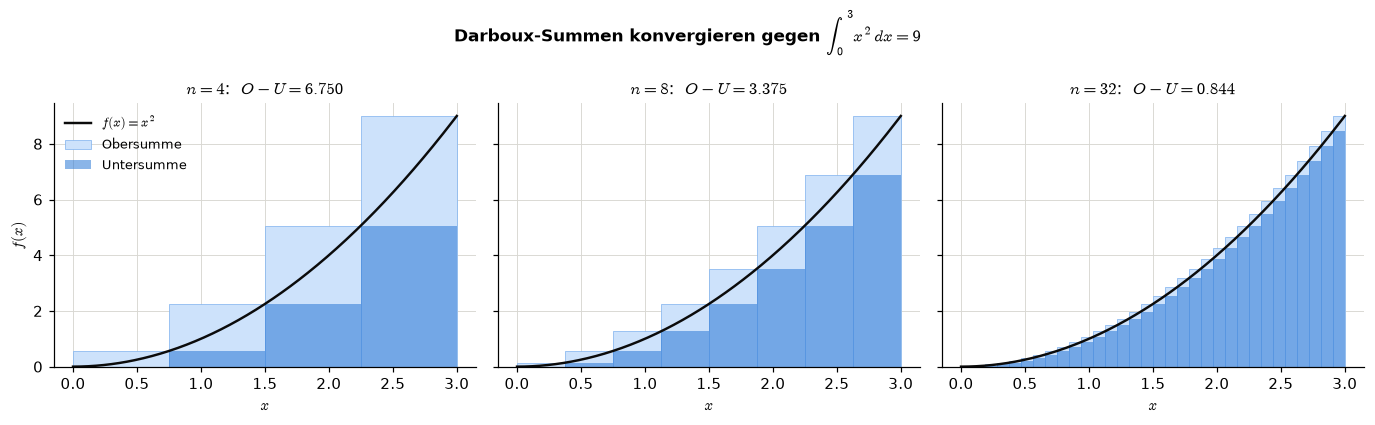

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9), sharey=True)
grid = np.linspace(a_demo, b_demo, 400)

for ax, n in zip(axes, (4, 8, 32)):
    edges = np.linspace(a_demo, b_demo, n + 1)
    h = (b_demo - a_demo) / n
    lo, hi, _ = riemann_sums(f_demo, a_demo, b_demo, n)

    ax.bar(edges[:-1], f_demo(edges[1:]), width=h, align="edge",
           color="#cde2fb", edgecolor="#86b6ef", linewidth=0.5, label="Obersumme")
    ax.bar(edges[:-1], f_demo(edges[:-1]), width=h, align="edge",
           color="#2a78d6", alpha=0.55, edgecolor="none", label="Untersumme")
    ax.plot(grid, f_demo(grid), color="#0b0b0b", linewidth=1.6, label="$f(x)=x^2$")
    ax.set_title(rf"$n={n}$:  $O-U = {hi - lo:.3f}$")
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")
axes[0].legend(fontsize=8.5, loc="upper left")
fig.suptitle(r"Darboux-Summen konvergieren gegen $\int_0^3 x^2\,dx = 9$",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

**Abbildung 3.1** — Unter- und Obersumme umschließen das Integral. Die Differenz $O - U$ halbiert
sich bei jeder Verdopplung von $n$, entsprechend der Ordnung $1$ aus Satz 1.2.

<a id="2"></a>
## 2 Der Hauptsatz

> **Satz 2.1 (Hauptsatz der Differential- und Integralrechnung).** Sei $f : [a,b] \to \mathbb{R}$ stetig.
>
> 1. Die Integralfunktion $F(x) = \int_a^x f(t)\,dt$ ist differenzierbar mit $F' = f$.
> 2. Ist $G$ eine beliebige Stammfunktion von $f$, so gilt
>    $\displaystyle\int_a^b f(t)\,dt = G(b) - G(a)$.
>
> *Beweis von (1).* Für $h \ne 0$ ist
> $\tfrac{1}{h}\big(F(x+h)-F(x)\big) = \tfrac{1}{h}\int_x^{x+h} f(t)\,dt = f(\xi_h)$ für ein
> $\xi_h$ zwischen $x$ und $x+h$ (Mittelwertsatz der Integralrechnung). Mit $h \to 0$ folgt
> $\xi_h \to x$ und wegen der Stetigkeit $f(\xi_h) \to f(x)$.
> *(2)* folgt aus (1), da sich zwei Stammfunktionen nur um eine Konstante unterscheiden. $\square$

**Beispiel 2.2.** Mit $G(x) = \tfrac{x^3}{3}$ ist
$\int_0^3 x^2\,dx = G(3)-G(0) = 9 - 0 = 9$ — der exakte Wert, gegen den die Summen in
Abbildung 3.1 konvergieren.

Der Hauptsatz löst das Problem allerdings nur, wenn eine Stammfunktion in geschlossener Form
existiert. Das ist die Ausnahme: Bereits $\int e^{-x^2}dx$ besitzt keine elementare
Stammfunktion, und genau dieses Integral ist die Normierungskonstante der Normalverteilung.
Damit ist die numerische Quadratur kein Notbehelf, sondern der Regelfall.

In [5]:
# Beispiel 2.2 und ein Integral ohne elementare Stammfunktion
value, abserr = integrate.quad(f_demo, 0.0, 3.0)
print(f"Hauptsatz:  G(3) - G(0) = {3 ** 3 / 3 - 0:.15f}")
print(f"numerisch:  quad        = {value:.15f}   (geschätzter Fehler {abserr:.1e})")

gauss = lambda x: np.exp(-x ** 2)
value, abserr = integrate.quad(gauss, -np.inf, np.inf)
print(f"\nkeine elementare Stammfunktion: ∫ exp(-x²) dx über R")
print(f"  numerisch = {value:.15f}")
print(f"  exakt     = {np.sqrt(np.pi):.15f}  (= sqrt(pi))")
print(f"  Abweichung: {abs(value - np.sqrt(np.pi)):.2e}")

Hauptsatz:  G(3) - G(0) = 9.000000000000000
numerisch:  quad        = 9.000000000000002   (geschätzter Fehler 1.0e-13)

keine elementare Stammfunktion: ∫ exp(-x²) dx über R
  numerisch = 1.772453850905516
  exakt     = 1.772453850905516  (= sqrt(pi))
  Abweichung: 0.00e+00


<a id="3"></a>
## 3 Newton–Cotes-Formeln: Trapez und Simpson

Die Idee der Newton–Cotes-Formeln: Ersetze $f$ auf jedem Teilintervall durch ein
Interpolationspolynom und integriere dieses exakt.

> **Definition 3.1.** Sei $h = (b-a)/n$ und $x_i = a + ih$. Die *zusammengesetzte Trapezregel* und
> die *zusammengesetzte Simpson-Regel* ($n$ gerade) lauten
> $$T_n(f) = h\Big(\tfrac{f(x_0)}{2} + \sum_{i=1}^{n-1} f(x_i) + \tfrac{f(x_n)}{2}\Big),
> \qquad
> S_n(f) = \frac{h}{3}\Big(f(x_0) + 4\!\!\sum_{i \text{ ungerade}}\!\! f(x_i)
> + 2\!\!\sum_{i \text{ gerade}, \, i \neq 0, n}\!\! f(x_i) + f(x_n)\Big).$$

> **Satz 3.2 (Fehlerdarstellung).** Ist $f \in C^2[a,b]$ bzw. $f \in C^4[a,b]$, so existieren
> $\xi, \zeta \in (a,b)$ mit
> $$\int_a^b f - T_n(f) = -\frac{(b-a)h^2}{12}\,f''(\xi) = \mathcal{O}(h^2),
> \qquad
> \int_a^b f - S_n(f) = -\frac{(b-a)h^4}{180}\,f^{(4)}(\zeta) = \mathcal{O}(h^4).$$

Bemerkenswert an der Simpson-Regel ist, dass sie durch quadratische Interpolation konstruiert
wird, aber **kubische** Polynome exakt integriert: Der Fehlerterm der dritten Ordnung hebt sich
aus Symmetriegründen auf. Diese Beobachtung führt direkt zur Frage des nächsten Abschnitts —
wie viel Exaktheit lässt sich mit $n$ Funktionsauswertungen maximal erreichen?

In [6]:
def trapezoid_rule(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return float(h * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1]))


def simpson_rule(f, a, b, n):
    if n % 2:
        raise ValueError("Die Simpson-Regel benötigt eine gerade Anzahl Teilintervalle.")
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return float(h / 3 * (y[0] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum() + y[-1]))


# Testintegral mit glattem, nicht polynomialem Integranden
f_test = lambda x: np.exp(np.sin(x))
a_t, b_t = 0.0, 2.0
exact_t = integrate.quad(f_test, a_t, b_t, epsabs=1e-13, epsrel=1e-13)[0]

ns = 2 ** np.arange(1, 13)
err_trap = np.array([abs(trapezoid_rule(f_test, a_t, b_t, int(n)) - exact_t) for n in ns])
err_simp = np.array([abs(simpson_rule(f_test, a_t, b_t, int(n)) - exact_t) for n in ns])
err_mid = np.array([abs(riemann_sums(f_test, a_t, b_t, int(n))[2] - exact_t) for n in ns])

h_values = (b_t - a_t) / ns
for name, err in [("Mittelpunkt", err_mid), ("Trapez", err_trap), ("Simpson", err_simp)]:
    valid = err > 1e-14
    order = np.polyfit(np.log(h_values[valid]), np.log(err[valid]), 1)[0]
    print(f"{name:<12} empirische Ordnung p = {order:.3f}")

Mittelpunkt  empirische Ordnung p = 2.004
Trapez       empirische Ordnung p = 2.002
Simpson      empirische Ordnung p = 4.002


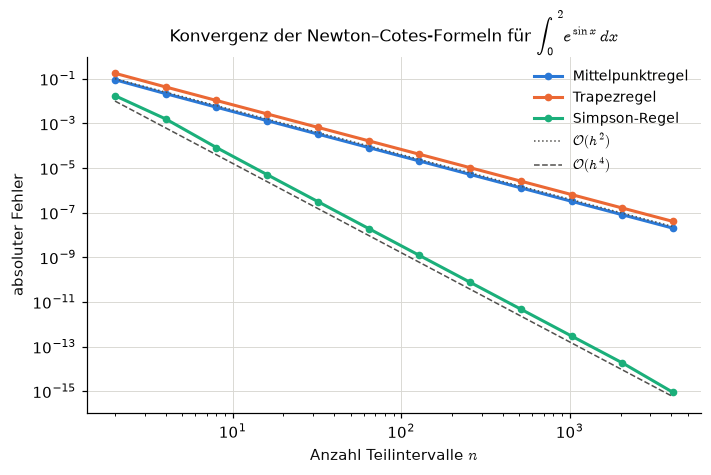

In [7]:
fig, ax = plt.subplots()
for (name, err), color in zip(
        [("Mittelpunktregel", err_mid), ("Trapezregel", err_trap), ("Simpson-Regel", err_simp)],
        PALETTE):
    ax.loglog(ns, np.maximum(err, 1e-17), marker="o", markersize=4, color=color, label=name)

ax.loglog(ns, 1e-1 * (ns / 2.0) ** -2.0, color="#52514e", linestyle=":", linewidth=1.0,
          label=r"$\mathcal{O}(h^2)$")
ax.loglog(ns, 1e-2 * (ns / 2.0) ** -4.0, color="#52514e", linestyle="--", linewidth=1.0,
          label=r"$\mathcal{O}(h^4)$")

ax.set_xlabel("Anzahl Teilintervalle $n$")
ax.set_ylabel("absoluter Fehler")
ax.set_title(r"Konvergenz der Newton–Cotes-Formeln für $\int_0^2 e^{\sin x}\,dx$")
ax.legend(fontsize=9)
plt.show()

**Abbildung 3.2** — Fehler über der Intervallzahl. Mittelpunkt- und Trapezregel fallen mit
Steigung $-2$, die Simpson-Regel mit $-4$; die gemessenen Ordnungen stimmen bis auf zwei
Nachkommastellen mit Satz 3.2 überein. Ab etwa $10^{-15}$ dominiert der Rundungsfehler der
Summation, und die Kurven flachen ab — dasselbe Phänomen wie bei der numerischen Differentiation
(Notebook 2, Abbildung 2.1), hier allerdings erst dicht an der Maschinengenauigkeit, weil die
Quadratur Werte *aufsummiert* statt sie zu subtrahieren.

Die Mittelpunktregel ist übrigens trotz gleicher Ordnung der Trapezregel überlegen: Ihre
Fehlerkonstante ist $+\tfrac{(b-a)h^2}{24}$ statt $-\tfrac{(b-a)h^2}{12}$, also halb so groß und
mit umgekehrtem Vorzeichen. Aus dieser Beobachtung lässt sich die Simpson-Regel als
Linearkombination beider gewinnen (Aufgabe 3.2).

<a id="4"></a>
## 4 Gauß–Legendre-Quadratur

Newton–Cotes-Formeln legen die Knoten äquidistant fest. Lässt man auch die Knoten frei, so stehen
für $n$ Knoten $2n$ Freiheitsgrade zur Verfügung — Knoten und Gewichte —, und man kann verlangen,
dass alle Polynome bis zum Grad $2n-1$ exakt integriert werden.

> **Satz 4.1 (Gauß).** Zu jedem $n \in \mathbb{N}$ existieren eindeutige Knoten
> $x_1 < \dots < x_n$ in $(-1,1)$ und Gewichte $w_1,\dots,w_n > 0$ mit
> $$\int_{-1}^{1} p(x)\,dx = \sum_{i=1}^n w_i\, p(x_i) \qquad \text{für alle Polynome } p
> \text{ vom Grad} \le 2n-1 .$$
> Die Knoten sind die Nullstellen des $n$-ten Legendre-Polynoms $P_n$. Höher als $2n-1$ geht es
> nicht: Für $p(x) = \prod_i (x-x_i)^2$ vom Grad $2n$ ist die rechte Seite null, die linke aber
> positiv.
>
> *Beweisidee.* Polynomdivision $p = q P_n + r$ mit $\deg q, \deg r \le n-1$. Der Term $qP_n$
> integriert sich wegen der Orthogonalität von $P_n$ zu allen Polynomen kleineren Grades zu null,
> und an den Knoten verschwindet er ebenfalls; für $r$ ist die Formel als Interpolationsquadratur
> exakt. $\square$

Für ein allgemeines Intervall $[a,b]$ überträgt die affine Substitution
$x = \tfrac{b-a}{2}t + \tfrac{a+b}{2}$ die Formel mit dem Faktor $\tfrac{b-a}{2}$.

In [8]:
def gauss_legendre(f, a, b, n):
    """Gauss-Legendre-Quadratur mit n Knoten auf [a, b]."""
    t, w = np.polynomial.legendre.leggauss(n)
    x = 0.5 * (b - a) * t + 0.5 * (a + b)
    return float(0.5 * (b - a) * np.sum(w * f(x)))


# Exaktheitsgrad nach Satz 4.1: n Knoten integrieren Grad <= 2n-1 exakt.
# Gerechnet wird auf [0, 1]: auf dem symmetrischen Intervall [-1, 1] verschwinden
# alle ungeraden Monome ohnehin, was den Exaktheitsgrad verschleiern wuerde.
n_nodes = 4
print(f"Gauß-Legendre mit n = {n_nodes} Knoten auf [0, 1]   (exakt bis Grad 2n-1 = {2 * n_nodes - 1}):")
print(f"{'Grad k':>7} | {'numerisch':>16} | {'exakt':>16} | {'Fehler':>10}")
print("-" * 62)
for k in range(2 * n_nodes + 3):
    approx = gauss_legendre(lambda x, k=k: x ** k, 0.0, 1.0, n_nodes)
    exact = 1.0 / (k + 1)
    flag = "" if abs(approx - exact) < 1e-12 else "   <- nicht mehr exakt"
    print(f"{k:>7} | {approx:>16.12f} | {exact:>16.12f} | {abs(approx - exact):>10.1e}{flag}")

Gauß-Legendre mit n = 4 Knoten auf [0, 1]   (exakt bis Grad 2n-1 = 7):
 Grad k |        numerisch |            exakt |     Fehler
--------------------------------------------------------------
      0 |   1.000000000000 |   1.000000000000 |    0.0e+00
      1 |   0.500000000000 |   0.500000000000 |    0.0e+00
      2 |   0.333333333333 |   0.333333333333 |    5.6e-17
      3 |   0.250000000000 |   0.250000000000 |    1.1e-16
      4 |   0.200000000000 |   0.200000000000 |    1.1e-16
      5 |   0.166666666667 |   0.166666666667 |    1.1e-16
      6 |   0.142857142857 |   0.142857142857 |    1.1e-16
      7 |   0.125000000000 |   0.125000000000 |    1.1e-16
      8 |   0.111088435374 |   0.111111111111 |    2.3e-05   <- nicht mehr exakt
      9 |   0.099897959184 |   0.100000000000 |    1.0e-04   <- nicht mehr exakt
     10 |   0.090641399417 |   0.090909090909 |    2.7e-04   <- nicht mehr exakt


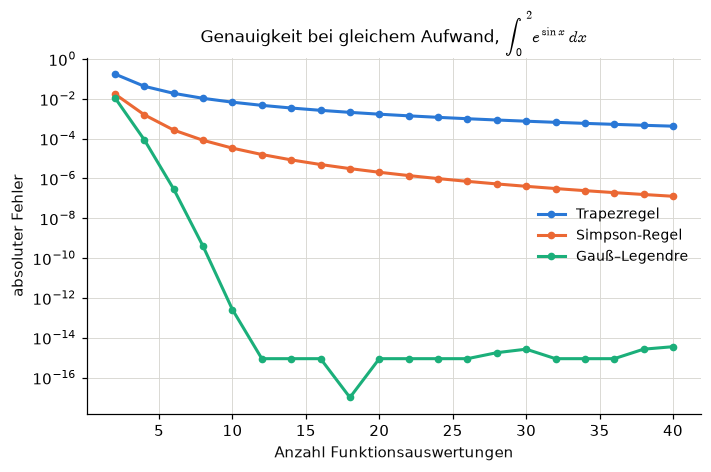

Bei 14 Auswertungen: Trapez 3.46e-03, Simpson 8.59e-06, Gauß 8.88e-16


In [9]:
# Genauigkeit bei gleichem Aufwand: Anzahl der Funktionsauswertungen als Vergleichsmass
evals = np.arange(2, 41, 2)
err_gauss = np.array([abs(gauss_legendre(f_test, a_t, b_t, int(m)) - exact_t) for m in evals])
err_simp_m = np.array([abs(simpson_rule(f_test, a_t, b_t, int(m)) - exact_t) for m in evals])
err_trap_m = np.array([abs(trapezoid_rule(f_test, a_t, b_t, int(m)) - exact_t) for m in evals])

fig, ax = plt.subplots()
for (name, err), color in zip(
        [("Trapezregel", err_trap_m), ("Simpson-Regel", err_simp_m),
         ("Gauß–Legendre", err_gauss)], PALETTE):
    ax.semilogy(evals, np.maximum(err, 1e-17), marker="o", markersize=4, color=color, label=name)

ax.set_xlabel("Anzahl Funktionsauswertungen")
ax.set_ylabel("absoluter Fehler")
ax.set_title(r"Genauigkeit bei gleichem Aufwand, $\int_0^2 e^{\sin x}\,dx$")
ax.legend(fontsize=9)
plt.show()

i = 6
print(f"Bei {evals[i]} Auswertungen: Trapez {err_trap_m[i]:.2e}, "
      f"Simpson {err_simp_m[i]:.2e}, Gauß {err_gauss[i]:.2e}")

**Abbildung 3.3** — Fehler über der Zahl der Funktionsauswertungen (halblogarithmisch). Die
Gauß–Legendre-Quadratur konvergiert für analytische Integranden **exponentiell**: Im
halblogarithmischen Diagramm ist ihre Kurve annähernd eine Gerade, während die
Newton–Cotes-Formeln als polynomiell konvergente Verfahren nach oben abknicken. Mit rund
$14$ Auswertungen erreicht Gauß Maschinengenauigkeit, wofür die Simpson-Regel mehrere hundert
benötigt.

Diese Überlegenheit setzt allerdings Glattheit voraus. Für Integranden mit Singularität oder
Sprung bricht sie zusammen — der Gegenstand des nächsten Abschnitts.

<a id="5"></a>
## 5 Adaptive Quadratur und Singularitäten

Feste Gitter verteilen den Aufwand gleichmäßig. Ist der Integrand aber nur auf einem kleinen
Teilbereich schwierig, ist das Verschwendung — und dort, wo es darauf ankommt, zu grob. Adaptive
Verfahren schätzen den lokalen Fehler und verfeinern nur, wo nötig; `scipy.integrate.quad`
implementiert dafür das QUADPACK-Verfahren mit Gauß–Kronrod-Paaren.

Wir betrachten zwei Problemfälle:

$$\text{(a) Spitze:}\quad \int_0^1 \frac{\alpha}{(x - 0{,}3)^2 + \alpha^2}\,dx,
\qquad
\text{(b) Wurzelsingularität:}\quad \int_0^1 \frac{dx}{\sqrt{x}} = 2 .$$

In (a) ist der Integrand glatt, aber mit $\alpha = 10^{-3}$ extrem lokalisiert; in (b) ist
$f$ bei $x = 0$ unbeschränkt, das Integral aber endlich. Beide Fälle sind für ein festes Gitter
ungünstig, wenn auch aus verschiedenen Gründen.

In [10]:
alpha = 1e-3
peak = lambda x: alpha / ((x - 0.3) ** 2 + alpha ** 2)
peak_exact = np.arctan((1 - 0.3) / alpha) - np.arctan((0 - 0.3) / alpha)

def sqrt_sing(x):
    """1/sqrt(x) mit dem Wert 0 an der Singularitaet x = 0.

    Der Funktionswert an einer einzelnen Stelle aendert das Integral nicht
    (Nullmenge); ohne diese Festlegung waere die Randauswertung der geschlossenen
    Newton-Cotes-Formeln nicht definiert."""
    x = np.asarray(x, dtype=float)
    positive = x > 0
    return np.where(positive, 1.0 / np.sqrt(np.where(positive, x, 1.0)), 0.0)


sqrt_exact = 2.0

print("(a) Spitze bei x = 0,3 mit Breite 1e-3")
for n in (100, 1_000, 10_000, 100_000):
    err = abs(simpson_rule(peak, 0.0, 1.0, n) - peak_exact)
    print(f"    Simpson, n = {n:>6}: Fehler {err:.3e}")
val, est = integrate.quad(peak, 0.0, 1.0, limit=200)
print(f"    quad (adaptiv):        Fehler {abs(val - peak_exact):.3e}, "
      f"geschätzt {est:.1e}")

print("\n(b) Wurzelsingularität bei x = 0")
for n in (100, 1_000, 10_000, 100_000):
    err = abs(simpson_rule(sqrt_sing, 0.0, 1.0, n) - sqrt_exact)
    print(f"    Simpson, n = {n:>6}: Fehler {err:.3e}")
val, est = integrate.quad(sqrt_sing, 0.0, 1.0)
print(f"    quad (adaptiv):        Fehler {abs(val - sqrt_exact):.3e}, "
      f"geschätzt {est:.1e}")

(a) Spitze bei x = 0,3 mit Breite 1e-3
    Simpson, n =    100: Fehler 3.906e+00
    Simpson, n =   1000: Fehler 7.892e-02
    Simpson, n =  10000: Fehler 4.841e-14
    Simpson, n = 100000: Fehler 4.441e-16
    quad (adaptiv):        Fehler 1.599e-14, geschätzt 2.4e-08

(b) Wurzelsingularität bei x = 0
    Simpson, n =    100: Fehler 1.259e-01
    Simpson, n =   1000: Fehler 3.980e-02
    Simpson, n =  10000: Fehler 1.259e-02
    Simpson, n = 100000: Fehler 3.980e-03
    quad (adaptiv):        Fehler 1.554e-15, geschätzt 5.8e-15


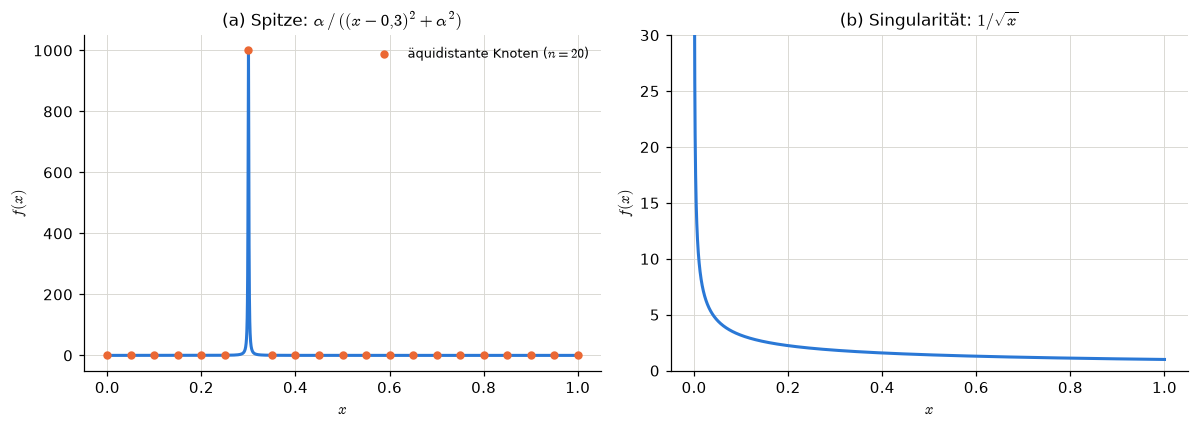

Simpson bei 1/sqrt(x): empirische Ordnung p = 0.500  (statt 4 bei glattem f)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

x_peak = np.linspace(0, 1, 4000)
axes[0].plot(x_peak, peak(x_peak), color=PALETTE[0])
axes[0].scatter(np.linspace(0, 1, 21), peak(np.linspace(0, 1, 21)), s=20,
                color=PALETTE[1], zorder=5, label="äquidistante Knoten ($n=20$)")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
axes[0].set_title(r"(a) Spitze: $\alpha\,/\,((x-0{,}3)^2+\alpha^2)$")
axes[0].legend(fontsize=8.5)

x_sing = np.linspace(1e-6, 1, 4000)
axes[1].plot(x_sing, sqrt_sing(x_sing), color=PALETTE[0])
axes[1].set_ylim(0, 30)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$f(x)$")
axes[1].set_title(r"(b) Singularität: $1/\sqrt{x}$")

plt.tight_layout()
plt.show()

# Konvergenzordnung bei der Singularitaet: die Glattheitsvoraussetzung faellt weg
ns_s = 2 ** np.arange(3, 16)
err_s = np.array([abs(simpson_rule(sqrt_sing, 0.0, 1.0, int(n)) - sqrt_exact) for n in ns_s])
order = np.polyfit(np.log(1.0 / ns_s), np.log(err_s), 1)[0]
print(f"Simpson bei 1/sqrt(x): empirische Ordnung p = {order:.3f}  (statt 4 bei glattem f)")

**Abbildung 3.4** — Die beiden Problemfälle. Links erfasst ein grobes äquidistantes Gitter die
Spitze überhaupt nicht: Alle Knoten liegen im flachen Bereich, das Verfahren „sieht“ den
wesentlichen Beitrag zum Integral nicht und liefert einen völlig falschen Wert, **ohne dass die
Formel dies anzeigen würde**. Rechts ist $f$ unbeschränkt; die Fehlerdarstellung aus Satz 3.2
setzt $f \in C^4$ voraus und ist nicht mehr anwendbar.

Die gemessene Ordnung bei der Wurzelsingularität liegt bei etwa $0{,}5$ statt bei $4$ — der
Genauigkeitsgewinn durch die höhere Formel ist vollständig verloren. Adaptive Verfahren erreichen
in beiden Fällen die geforderte Toleranz, weil sie das Gitter dort verdichten, wo der geschätzte
lokale Fehler groß ist. Die von `quad` zurückgegebene Fehlerschätzung ist dabei ein
verlässlicheres Qualitätsmerkmal als jede A-priori-Abschätzung mit unbekanntem $f^{(4)}(\zeta)$.

<a id="6"></a>
## 6 Monte-Carlo-Integration und der Fluch der Dimensionalität

Für $\Omega = [0,1]^d$ und $f : \Omega \to \mathbb{R}$ ist
$$I = \int_\Omega f(x)\,dx = \mathbb{E}[f(X)], \qquad X \sim \mathcal{U}(\Omega),$$
also ein Erwartungswert. Der naheliegende Schätzer ist das Stichprobenmittel.

> **Satz 6.1 (Monte-Carlo-Schätzer).** Seien $X_1,\dots,X_N$ unabhängig $\mathcal{U}(\Omega)$-verteilt
> und $\hat I_N = \tfrac{1}{N}\sum_{i=1}^N f(X_i)$. Ist $\sigma^2 = \operatorname{Var} f(X) < \infty$, so gilt
> $$\mathbb{E}[\hat I_N] = I, \qquad \operatorname{Var}(\hat I_N) = \frac{\sigma^2}{N},
> \qquad \text{also} \quad \mathbb{E}\big[(\hat I_N - I)^2\big]^{1/2} = \frac{\sigma}{\sqrt N} .$$
> Die Fehlerordnung $\mathcal{O}(N^{-1/2})$ ist **unabhängig von der Dimension $d$**.
>
> *Beweis.* Erwartungstreue folgt aus der Linearität; die Varianz aus der Unabhängigkeit:
> $\operatorname{Var}(\hat I_N) = N^{-2}\sum_i \operatorname{Var} f(X_i) = \sigma^2/N$. $\square$

Dem steht die Gitterquadratur gegenüber: Ein Tensorproduktgitter mit $n$ Knoten je Dimension
benötigt $N = n^d$ Auswertungen. Bei einer Formel der Ordnung $p$ ist der Fehler
$\mathcal{O}(n^{-p}) = \mathcal{O}(N^{-p/d})$ — die Ordnung **zerfällt mit der Dimension**. Für
die Trapezregel ($p=2$) sind beide Verfahren bei $d = 4$ gleichauf; darüber gewinnt Monte Carlo.

Für den Vergleich nutzen wir den separablen Integranden
$f(x) = \exp\big(\sum_{i=1}^d x_i\big)$ mit $I = (e-1)^d$. Wegen der Separabilität ist die
Tensorprodukt-Trapezregel gleich $T_n^{\,d}$ mit der eindimensionalen Trapezsumme $T_n$ — der
Fehler lässt sich also berechnen, ohne das $n^d$-Gitter je aufzubauen.

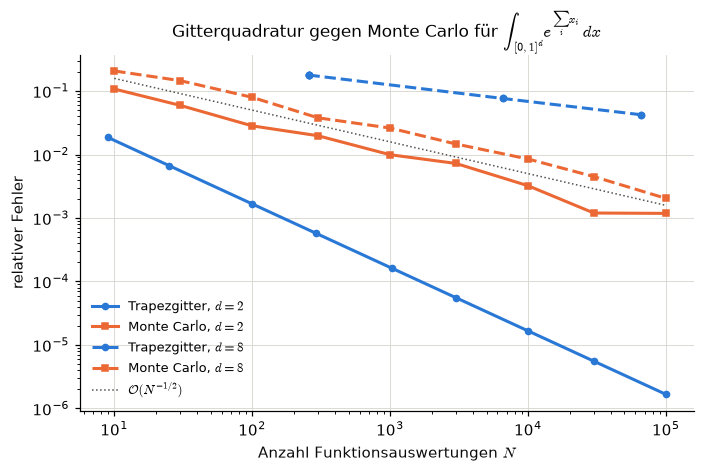

In [12]:
def grid_error(dim, n):
    """Fehler der Tensorprodukt-Trapezregel fuer exp(sum x_i) auf [0,1]^dim.

    Ausgenutzt wird die Separabilitaet: das d-dimensionale Gitterintegral ist
    die d-te Potenz der eindimensionalen Trapezsumme."""
    t_1d = trapezoid_rule(np.exp, 0.0, 1.0, n)
    return abs(t_1d ** dim - (np.e - 1.0) ** dim) / (np.e - 1.0) ** dim


def monte_carlo_error(dim, n_samples, n_repeats=30, rng=rng):
    """Mittlerer relativer Fehler des Monte-Carlo-Schaetzers ueber n_repeats Wiederholungen."""
    exact = (np.e - 1.0) ** dim
    errs = [abs(np.mean(np.exp(rng.random((n_samples, dim)).sum(axis=1))) - exact) / exact
            for _ in range(n_repeats)]
    return float(np.mean(errs))


budgets = np.array([10, 30, 100, 300, 1_000, 3_000, 10_000, 30_000, 100_000])

fig, ax = plt.subplots()
for dim, style in [(2, "-"), (8, "--")]:
    n_per_dim = np.maximum(np.round(budgets ** (1.0 / dim)).astype(int), 2)
    actual = n_per_dim ** dim
    ax.loglog(actual, [grid_error(dim, int(n)) for n in n_per_dim], style, marker="o",
              markersize=4, color=PALETTE[0], label=f"Trapezgitter, $d={dim}$")
    ax.loglog(budgets, [monte_carlo_error(dim, int(N)) for N in budgets], style, marker="s",
              markersize=4, color=PALETTE[1], label=f"Monte Carlo, $d={dim}$")

ax.loglog(budgets, 0.5 * budgets ** -0.5, color="#52514e", linestyle=":", linewidth=1.0,
          label=r"$\mathcal{O}(N^{-1/2})$")
ax.set_xlabel("Anzahl Funktionsauswertungen $N$")
ax.set_ylabel("relativer Fehler")
ax.set_title(r"Gitterquadratur gegen Monte Carlo für $\int_{[0,1]^d} e^{\sum_i x_i}\,dx$")
ax.legend(fontsize=8.5)
plt.show()

In [13]:
# Ab welcher Dimension ist Monte Carlo bei festem Budget ueberlegen?
N_budget = 10_000
print(f"Budget: {N_budget} Funktionsauswertungen\n")
print(f"{'d':>3} | {'n je Dim.':>10} | {'Trapezgitter':>14} | {'Monte Carlo':>14} | besser")
print("-" * 62)
for dim in range(1, 11):
    n_per_dim = max(int(round(N_budget ** (1.0 / dim))), 2)
    e_grid = grid_error(dim, n_per_dim)
    e_mc = monte_carlo_error(dim, N_budget)
    print(f"{dim:>3} | {n_per_dim:>10} | {e_grid:>14.3e} | {e_mc:>14.3e} | "
          f"{'Gitter' if e_grid < e_mc else 'Monte Carlo'}")

Budget: 10000 Funktionsauswertungen

  d |  n je Dim. |   Trapezgitter |    Monte Carlo | besser
--------------------------------------------------------------
  1 |      10000 |      8.333e-10 |      2.160e-03 | Gitter
  2 |        100 |      1.667e-05 |      4.081e-03 | Gitter
  3 |         22 |      5.166e-04 |      5.330e-03 | Gitter
  4 |         10 |      3.337e-03 |      4.159e-03 | Gitter
  5 |          6 |      1.162e-02 |      5.920e-03 | Monte Carlo
  6 |          5 |      2.015e-02 |      6.995e-03 | Monte Carlo
  7 |          4 |      3.699e-02 |      6.655e-03 | Monte Carlo
  8 |          3 |      7.637e-02 |      7.689e-03 | Monte Carlo
  9 |          3 |      8.632e-02 |      7.642e-03 | Monte Carlo
 10 |          3 |      9.636e-02 |      9.448e-03 | Monte Carlo


**Abbildung 3.5** — Relativer Fehler über dem Aufwand. Die Monte-Carlo-Kurven liegen für $d=2$
und $d=8$ praktisch übereinander und folgen der Referenzgeraden $N^{-1/2}$: Die Dimension geht in
die Rate nicht ein. Die Gitterkurven trennen sich dagegen deutlich — bei $d=8$ ist die effektive
Ordnung nur noch $2/8 = 0{,}25$.

Die Tabelle beziffert den Umschlagpunkt: Bis etwa $d = 4$ ist das Gitter genauer, darüber
Monte Carlo. Genau deshalb sind in der Bayes-Statistik und im probabilistischen Maschinellen
Lernen — wo über Parameterräume mit Hunderten bis Millionen Dimensionen integriert wird —
stochastische Verfahren (MCMC, Variationsinferenz, Importance Sampling) alternativlos.

Zu beachten ist allerdings die Konstante: $\mathcal{O}(N^{-1/2})$ bedeutet, dass eine zusätzliche
Dezimalstelle Genauigkeit den hundertfachen Aufwand kostet. Varianzreduktion — Kontrollvariablen,
Importance Sampling, Quasi-Monte-Carlo — setzt an $\sigma$ an, nicht an der Rate, und ist deshalb
in der Praxis entscheidend.

<a id="7"></a>
## 7 Anwendung: Normierungskonstanten

Eine Dichte muss sich zu $1$ integrieren. Für die Normalverteilung
$\varphi(x) = \tfrac{1}{\sqrt{2\pi}}e^{-x^2/2}$ ist das die Aussage
$\int_{\mathbb{R}} e^{-x^2/2}dx = \sqrt{2\pi}$, klassisch bewiesen über den Übergang zu
Polarkoordinaten im $\mathbb{R}^2$. In der Bayes-Statistik tritt dasselbe Problem in der
Evidenz auf:
$$p(y) \;=\; \int_\Theta p(y \mid \theta)\,p(\theta)\,d\theta ,$$
einem Integral über den gesamten Parameterraum, das in aller Regel nur numerisch zugänglich ist.
Wir prüfen Normierung, Erwartungswert und Varianz einer Normalverteilung numerisch — ein
Standardtest, mit dem sich Implementierungsfehler in Dichten zuverlässig aufdecken lassen.

In [14]:
mu_n, sigma_n = 1.5, 0.8
normal_pdf = lambda x: np.exp(-0.5 * ((x - mu_n) / sigma_n) ** 2) / (sigma_n * np.sqrt(2 * np.pi))

moments = {
    "Normierung  ∫ p(x) dx":     (integrate.quad(normal_pdf, -np.inf, np.inf), 1.0),
    "Erwartungswert ∫ x p(x) dx": (integrate.quad(lambda x: x * normal_pdf(x), -np.inf, np.inf), mu_n),
    "Varianz ∫ (x-µ)² p(x) dx":  (integrate.quad(lambda x: (x - mu_n) ** 2 * normal_pdf(x),
                                                 -np.inf, np.inf), sigma_n ** 2),
}

print(f"{'Größe':<28} | {'numerisch':>14} | {'exakt':>10} | {'Abweichung':>11}")
print("-" * 74)
for name, ((value, err), exact) in moments.items():
    print(f"{name:<28} | {value:>14.10f} | {exact:>10.4f} | {abs(value - exact):>11.2e}")

# Die Fehlerfunktion als Stammfunktion: P(X <= b) in geschlossener Form
b = 2.0
cdf_quad = integrate.quad(normal_pdf, -np.inf, b)[0]
cdf_erf = 0.5 * (1 + special.erf((b - mu_n) / (sigma_n * np.sqrt(2))))
print(f"\nP(X <= {b}):  Quadratur {cdf_quad:.12f}   über erf {cdf_erf:.12f}   "
      f"Differenz {abs(cdf_quad - cdf_erf):.2e}")

Größe                        |      numerisch |      exakt |  Abweichung
--------------------------------------------------------------------------
Normierung  ∫ p(x) dx        |   1.0000000000 |     1.0000 |    1.11e-16
Erwartungswert ∫ x p(x) dx   |   1.5000000000 |     1.5000 |    2.22e-16
Varianz ∫ (x-µ)² p(x) dx     |   0.6400000000 |     0.6400 |    9.99e-16

P(X <= 2.0):  Quadratur 0.734014470951   über erf 0.734014470951   Differenz 3.33e-16


<a id="8"></a>
## 8 Übungsaufgaben

**Aufgabe 3.1 (Fehlerdarstellung).** Leiten Sie die Fehlerformel der Trapezregel für ein einzelnes
Teilintervall über die Interpolationsfehlerformel
$f(x) - p_1(x) = \tfrac{f''(\xi_x)}{2}(x-x_0)(x-x_1)$ her und zeigen Sie durch Aufsummieren die
Aussage von Satz 3.2 für die zusammengesetzte Regel.

**Aufgabe 3.2 (Romberg-Extrapolation).** Zeigen Sie, dass
$S_n = \tfrac{2}{3}M_{n/2} + \tfrac{1}{3}T_{n/2}$ gilt, wobei $M$ die Mittelpunkt- und $T$ die
Trapezsumme bezeichnet. Implementieren Sie darauf aufbauend das Romberg-Verfahren und weisen Sie
empirisch die Ordnung $\mathcal{O}(h^{6})$ der zweiten Extrapolationsstufe nach.

**Aufgabe 3.3 (Substitution bei Singularitäten).** Zeigen Sie, dass die Substitution $x = t^2$ das
Integral $\int_0^1 x^{-1/2}dx$ in ein Integral mit glattem Integranden überführt. Vergleichen Sie
die Konvergenzordnung der Simpson-Regel vor und nach der Substitution.

**Aufgabe 3.4 (Varianzreduktion).** Schätzen Sie $\int_0^1 e^x dx$ per Monte Carlo einmal direkt
und einmal mit der Kontrollvariablen $g(x) = 1 + x$ (deren Integral bekannt ist). Bestimmen Sie
empirisch den Varianzreduktionsfaktor und vergleichen Sie ihn mit
$1 - \rho^2$, wobei $\rho$ die Korrelation von $f(X)$ und $g(X)$ ist.

**Aufgabe 3.5 (Quasi-Monte-Carlo).** Ersetzen Sie in Abschnitt 6 die Pseudozufallszahlen durch
eine Sobol-Folge (`scipy.stats.qmc.Sobol`). Bestimmen Sie die empirische Konvergenzordnung für
$d = 2$ und $d = 8$ und erklären Sie, weshalb der theoretische Vorteil
$\mathcal{O}(N^{-1}(\log N)^d)$ mit wachsender Dimension verschwindet.

---

## Literatur

- Davis, P. J., Rabinowitz, P. (1984). *Methods of Numerical Integration.* 2. Auflage, Academic Press.
- Deuflhard, P., Hohmann, A. (2008). *Numerische Mathematik 1.* 4. Auflage, de Gruyter, Kapitel 9.
- Königsberger, K. (2004). *Analysis 1.* 6. Auflage, Springer, Kapitel 11–12.
- Piessens, R., de Doncker-Kapenga, E., Überhuber, C., Kahaner, D. (1983). *QUADPACK — A
  Subroutine Package for Automatic Integration.* Springer.
- Robert, C. P., Casella, G. (2004). *Monte Carlo Statistical Methods.* 2. Auflage, Springer.
- Stoer, J., Bulirsch, R. (2005). *Numerische Mathematik 1.* 10. Auflage, Springer, Kapitel 3.